In [10]:
import graph_tool.collection 
import graph_tool.search 
import graph_tool as gt
import random
import numpy as np
import zstandard
import networkx as nx
import copy
import osmnx as ox

import random
from collections import defaultdict
import matplotlib.pyplot as plt
import os
import subprocess
import ast
import numpy as np

In [11]:
np.sqrt(8.5**2-64)

2.8722813232690143

In [13]:
np.sqrt(64+9)

8.54400374531753

In [2]:
%load_ext autoreload
%autoreload 2

from src import utils as ut


In [3]:
place = 'Kyoto, Japan'
g = ut.get_nx_from_ox(place)
wgt = 'length'

G = ox.graph_from_place(place, network_type='drive')

In [4]:
st_pairs = 10 #number of source, target pairs

In [5]:
st = ut.sample_st(g,st_pairs, seed = 115)


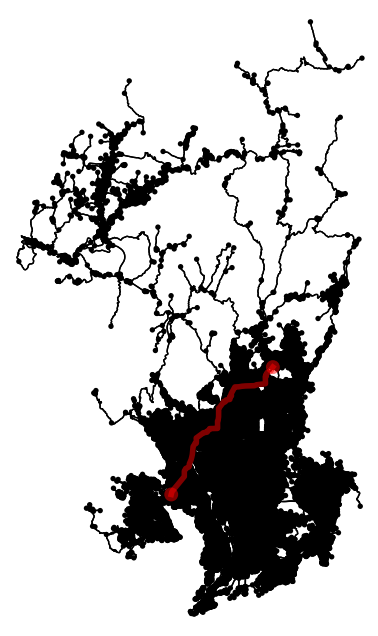

In [6]:
orig_node,dest_node = st[0][1],st[1][1]
orig_node,dest_node = 1369782971, 1328386576
route = nx.shortest_path(g, orig_node, dest_node, weight='length',method='dijkstra')
fig, ax = ox.plot_graph_route(G, route, bgcolor='white', edge_color='black', node_color='black')

In [7]:
route

[1369782971,
 1313663791,
 1305639013,
 1700932510,
 1313663271,
 1305638427,
 311263916,
 1305638691,
 311263814,
 1305639241,
 1305638566,
 260740954,
 833796367,
 1305638995,
 1305638493,
 1305638992,
 1305638526,
 833796334,
 802152674,
 833796335,
 833796333,
 802152675,
 833796341,
 691338583,
 1312572511,
 691338572,
 1312572527,
 1316867776,
 310401243,
 1316867521,
 1316867213,
 1312572432,
 1316867120,
 1316867606,
 802152659,
 260739709,
 309121317,
 1244294531,
 1316867737,
 1244292525,
 1244292431,
 1316867421,
 1244292390,
 311266942,
 310401195,
 1316867724,
 2276856988,
 1244292317,
 1314949990,
 802198582,
 309121337,
 1244292342,
 1307619043,
 1244292462,
 309121338,
 1691686196,
 529263204,
 1311739677,
 1244292487,
 1691686195,
 1304614904,
 309121339,
 1304614939,
 1304615114,
 1304614819,
 1304479101,
 1316867414,
 1303580449,
 1303580310,
 1312572462,
 1316867226,
 1316867784,
 1312572416,
 1312572595,
 1304615278,
 2102887880,
 1307453939,
 1307454777,
 13074535

In [8]:
folder_path = "/Users/antonioferrara/Desktop/GitHub/Maxmin-Fair-Paths/kspwlo-master/"
os.chdir(folder_path)
node_map = ut.save_graph_to_gr(g, 'tmp.gr', source=orig_node, target=dest_node,weight = wgt)
EKSP_node_map = ut.save_graph_to_gr_EKSP(g, 'tmp_EKSP.gr', source=orig_node, target=dest_node,weight = wgt)


In [9]:
ut.inverse_mapping([[1,2,3]],EKSP_node_map)


[[224811793, 224811818, 224811845]]

In [10]:
ut.inverse_mapping([[0,1,2]],node_map)


[[224811793, 224811818, 224811845]]

In [11]:
with open('tmpQ.txt', 'w') as file:
    file.write(f"{EKSP_node_map[orig_node]} {EKSP_node_map[dest_node]}\n")

In [12]:
dag = ut.get_dag(g, orig_node, dest_node, weight=wgt)
dag.nodes()

NodeView((243776603, 260739709, 260740945, 260740946, 260740949, 260740951, 260740953, 260740954, 260740956, 292753386, 292753387, 296272867, 298925586, 298925597, 298994754, 298994756, 298994758, 298995831, 298996954, 300228434, 300231256, 300231257, 303073078, 303073126, 303074698, 303075133, 303075315, 303075592, 303078008, 304192088, 304192091, 305536957, 309121314, 309121315, 309121317, 309121326, 309121337, 309121338, 309121339, 309121348, 309121349, 309353893, 309353915, 309372089, 309372090, 309383462, 310401195, 310401240, 310401243, 310718822, 310718827, 311263642, 311263814, 311263916, 311265699, 311265706, 311265813, 311266092, 311266093, 311266095, 311266803, 311266942, 311266946, 311266948, 312760584, 312760589, 312760596, 312760600, 312760606, 312760611, 312760627, 312760636, 312970260, 312973347, 312973348, 312974234, 312974801, 312974809, 312974812, 312974815, 312975255, 312975259, 312975260, 312975267, 312975619, 312975621, 312976605, 312976607, 312976938, 312977320, 

In [13]:
%%time
dag = ut.get_dag(g, orig_node, dest_node, weight=wgt)
K, alpha, model, result = ut.iterative_solver(dag, orig_node, dest_node) #LP solver, alpha are the satisf. probs
final = ut.compute_probabilities_and_expectations(dag, result, dest_node) 
LP_dag = final['dag']
dag = G.subgraph(dag.nodes())

Set parameter Username
Academic license - for non-commercial use only - expires 2025-06-20
CPU times: user 2min 32s, sys: 1.22 s, total: 2min 33s
Wall time: 2min 34s


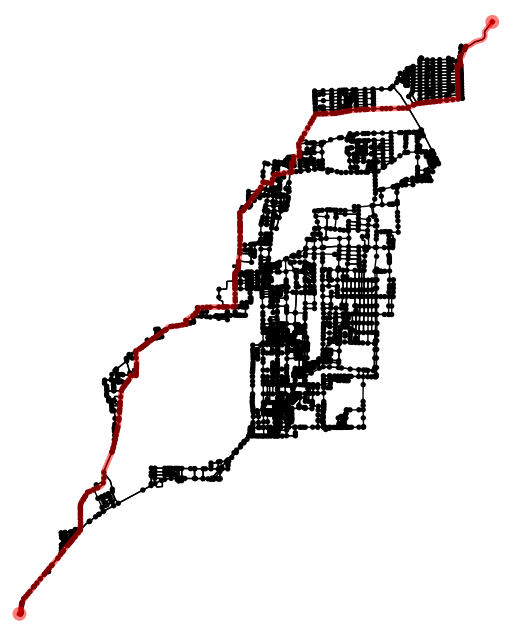

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [14]:

ox.plot_graph_route(dag, route, bgcolor='white', edge_color='black', node_color='black')

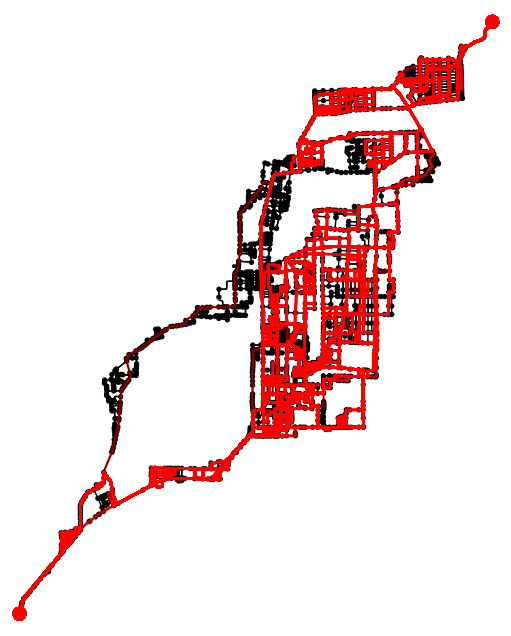

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [15]:
node_map = ut.save_graph_to_gr(dag, 'tmp.gr', source=orig_node, target=dest_node, weight=wgt)
kspwlo_paths_08_10 = ut.inverse_mapping(
    ut.execute_bash_command("tmp.gr", 200, 0.8, node_map[orig_node], node_map[dest_node], "esx-c"), node_map)
len(kspwlo_paths_08_10)
ox.plot_graph_routes(dag, kspwlo_paths_08_10  ,route_linewidths=2, bgcolor='white', edge_color='black', node_color='black')

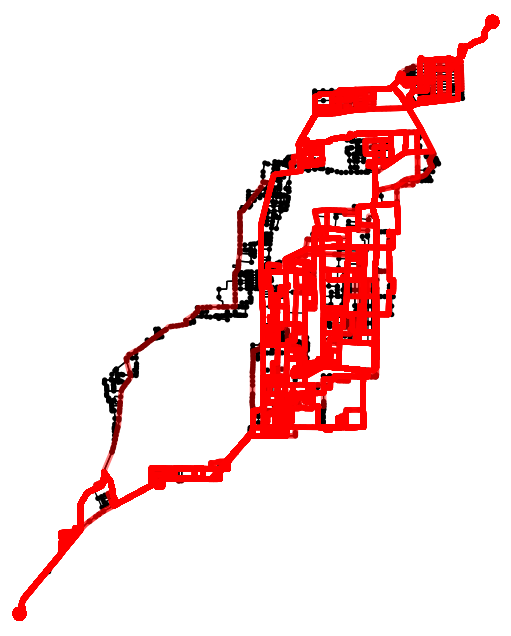

In [18]:
fig, ax = ox.plot_graph_routes(
    dag,
    kspwlo_paths_08_10,
    route_linewidth=2,
    bgcolor='white',
    edge_color='black',
    node_color='black'
)

# Save the plot as a PDF
filename = os.path.join('../FairShortPath/plot_paths/', f'{place}_ESXC200.pdf')
fig.savefig(filename, format="pdf", bbox_inches='tight')
plt.close(fig)


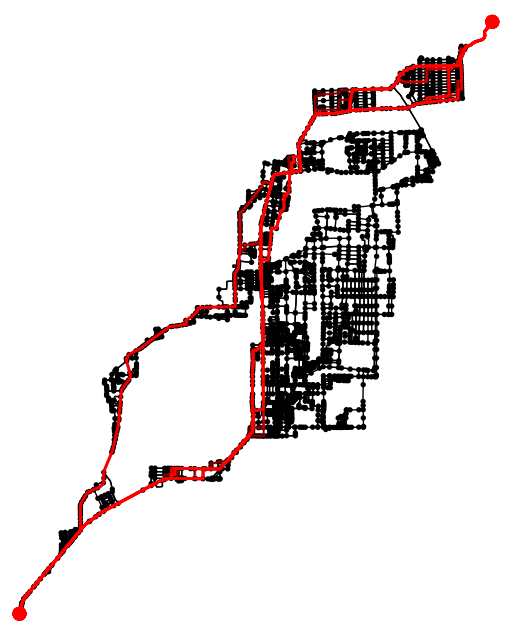

CPU times: user 1.43 s, sys: 1.59 s, total: 3.02 s
Wall time: 47min 15s


(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [19]:
%%time
node_map = ut.save_graph_to_gr(dag, 'tmp.gr', source=orig_node, target=dest_node, weight=wgt)
opplus20 = ut.inverse_mapping(
    ut.execute_bash_command("tmp.gr", 20, 0.8, node_map[orig_node], node_map[dest_node], "opplus"), node_map)
ox.plot_graph_routes(dag, opplus20  ,route_linewidths=2, bgcolor='white', edge_color='black', node_color='black')

In [ ]:
fig, ax = ox.plot_graph_routes(
    dag,
    kspwlo_paths_08_10,
    route_linewidth=2,
    bgcolor='white',
    edge_color='black',
    node_color='black'
)

# Save the plot as a PDF
filename = os.path.join(directory, f'{place}_ESXC200.pdf')
fig.savefig(filename, format="pdf", bbox_inches='tight')
plt.close(fig)

In [20]:
fair_fp = ut.sample_k_FP(LP_dag, orig_node, dest_node, 200)

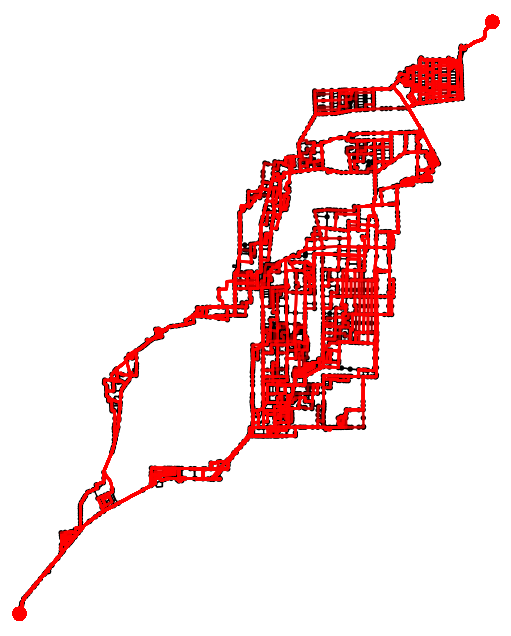

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [21]:
ox.plot_graph_routes(dag, fair_fp , route_linewidths=2, bgcolor='white', edge_color='black', node_color='black')

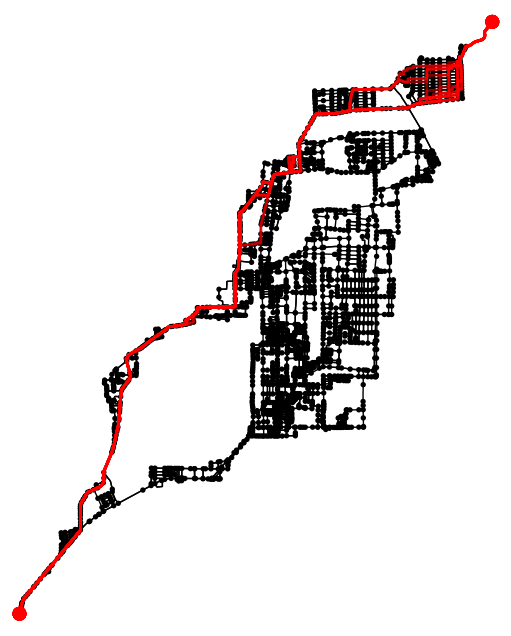

CPU times: user 1.18 s, sys: 1.53 s, total: 2.71 s
Wall time: 2min 6s


(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [60]:
%%time

EKSP_node_map = ut.save_graph_to_gr_EKSP(dag, 'tmp_EKSP.gr', source=orig_node, target=dest_node,weight = wgt)


with open('tmpQ.txt', 'w') as file:
        file.write(f"{EKSP_node_map[orig_node]} {EKSP_node_map[dest_node]}\n")


EKSP_paths_05_10 = ut.inverse_mapping(ut.execute_EKSP("tmp_EKSP.gr", 20, 0.8), node_map)#it is with node_map results shifted by 1
ox.plot_graph_routes(dag, EKSP_paths_05_10 , route_linewidths=2, bgcolor='white', edge_color='black', node_color='black')

In [ ]:
%%time

EKSP_node_map = ut.save_graph_to_gr_EKSP(dag, 'tmp_EKSP.gr', source=orig_node, target=dest_node,weight = wgt)


with open('tmpQ.txt', 'w') as file:
        file.write(f"{EKSP_node_map[orig_node]} {EKSP_node_map[dest_node]}\n")


EKSP_paths_05_4 = ut.inverse_mapping(ut.execute_EKSP("tmp_EKSP.gr", 4, 0.5), node_map)#it is with node_map results shifted by 1
ox.plot_graph_routes(dag, EKSP_paths_05_4 , route_linewidths=2, bgcolor='white', edge_color='black', node_color='black')

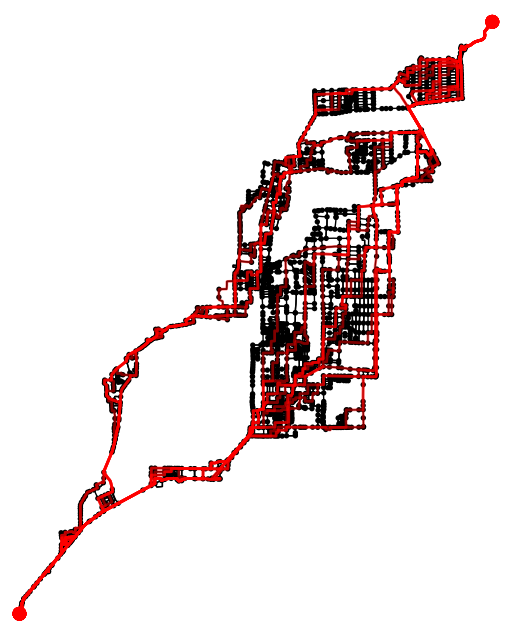

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [59]:
fair_fp = ut.sample_k_FP(LP_dag, orig_node, dest_node, 20)
ox.plot_graph_routes(dag, fair_fp , route_linewidths=2, bgcolor='white', edge_color='black', node_color='black')

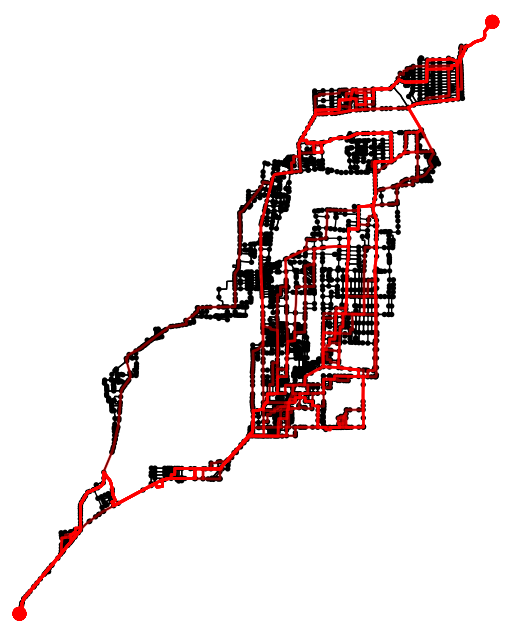

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [62]:
%%time
node_map = ut.save_graph_to_gr(dag, 'tmp.gr', source=orig_node, target=dest_node, weight=wgt)
kspwlo_paths_08_10 = ut.inverse_mapping(
    ut.execute_bash_command("tmp.gr", 20, 0.8, node_map[orig_node], node_map[dest_node], "esx-c"), node_map)
print(len(kspwlo_paths_08_10))
ox.plot_graph_routes(dag, kspwlo_paths_08_10  ,route_linewidths=2, bgcolor='white', edge_color='black', node_color='black')

In [63]:
print(len(kspwlo_paths_08_10))


20


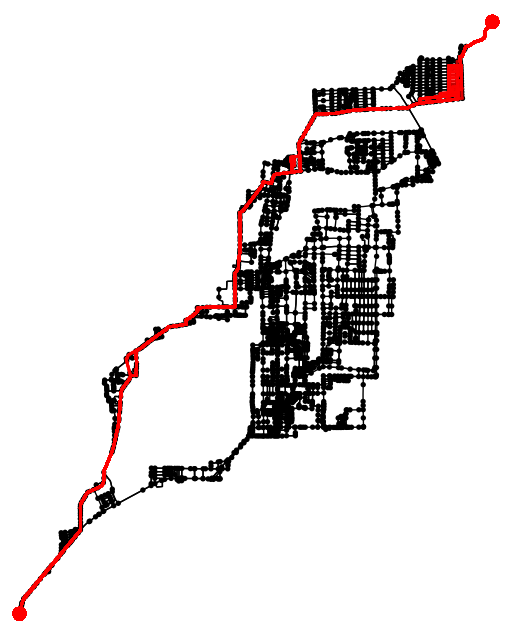

CPU times: user 35.6 s, sys: 226 ms, total: 35.8 s
Wall time: 35.4 s


(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [66]:
%%time
dag_yen = ut.get_dag(g, orig_node, dest_node, weight=wgt)
yen_k_shortest = ut.yen_k_paths(dag_yen, orig_node, dest_node, weight=wgt, k=200)
ox.plot_graph_routes(dag, yen_k_shortest  ,route_linewidths=2, bgcolor='white', edge_color='black', node_color='black')

In [ ]:
# Calculate mean and standard deviation for each method

# Function to calculate mean and standard deviation for runtimes
def calculate_runtime_mean_std(runtimes):
    runtime_mean = np.mean(runtimes)
    runtime_std = np.std(runtimes)
    return runtime_mean, runtime_std

# Function to calculate mean and standard deviation for results
def calculate_result_mean_std(results):
    result_mean = np.mean(results)
    result_std = np.std(results)
    return result_mean, result_std

# Function to calculate mean for path lengths
def calculate_length_mean(lengths):
    return np.mean(lengths)

methods = ["FP_paths", "random_FP_paths", 
           "yen_k_shortest_10", "esx-c_paths_05_10", "esx-c_paths_08_10", 
           "opplus_paths_05_10", "opplus_paths_08_10",
           #"yen_k_shortest_100",
           "esx-c_paths_05_100", "esx-c_paths_08_100",
           "EKSP_08_10"
           ]

results_lists = [results_FP_paths, results_random_FP_paths,
                 results_yen_k_shortest_10, results_kspwlo_paths_05_10, results_kspwlo_paths_08_10,
                 results_opplus_paths_05_10, results_opplus_paths_08_10,
                 #results_yen_k_shortest_100,
                 results_kspwlo_paths_05_100, results_kspwlo_paths_08_100,results_EKSP_paths_05_10]

runtimes_lists = [runtimes_FP_paths, runtimes_random_FP_paths,
                  runtimes_yen_k_shortest_10, runtimes_kspwlo_paths_05_10, runtimes_kspwlo_paths_08_10,
                  runtimes_opplus_paths_05_10, runtimes_opplus_paths_08_10,
                  #runtimes_yen_k_shortest_100,
                  runtimes_kspwlo_paths_05_100, runtimes_kspwlo_paths_08_100, runtimes_EKSP_paths_05_10]

lengths_lists = [lengths_FP_paths, lengths_random_FP_paths,
                 lengths_yen_k_shortest_10, lengths_kspwlo_paths_05_10, lengths_kspwlo_paths_08_10,
                 lengths_opplus_paths_05_10, lengths_opplus_paths_08_10,
                 #lengths_yen_k_shortest_100,
                 lengths_kspwlo_paths_05_100, lengths_kspwlo_paths_08_100, lengths_EKSP_paths_05_10]

gini_lists = [gini_FP_paths, gini_random_FP_paths,
                 gini_yen_k_shortest_10, gini_kspwlo_paths_05_10, gini_kspwlo_paths_08_10,
                 gini_opplus_paths_05_10, gini_opplus_paths_08_10,
                 #gini_yen_k_shortest_100,
                 gini_kspwlo_paths_05_100, gini_kspwlo_paths_08_100, gini_EKSP_paths_05_10]



data = []

for method, results, runtimes, lengths, gini in zip(methods, results_lists, runtimes_lists, lengths_lists,gini_lists):
    result_mean, result_std = calculate_result_mean_std(results)
    runtime_mean, runtime_std = calculate_runtime_mean_std(runtimes)
    length_mean, length_std = np.mean(lengths), np.std(lengths)
    gini_mean,gini_std = np.nanmean(gini), np.nanstd(gini)
    data.append([method, 
                 result_mean,
                 length_mean, length_std,
                 runtime_mean, runtime_std,
                 gini_mean,gini_std])
    
df = pd.DataFrame(data, columns=["Method",  "Number of paths",  
                                 "Length", "Std Length",
                                 "Runtime", "Std Runtime",
                                "Gini", "Gini Std"])

# Print the DataFrame
print(df)

file_path = f'../FairShortPath/results/{place}_new.csv'

# Save the DataFrame to a CSV file
df.to_csv(file_path, index=False)

In [ ]:
file_path = f'../FairShortPath/results/{place}_new.csv'
import pandas as pd
pd.read_csv(file_path)

In [ ]:
%time
sp_length,sp_nodes = ut.list_shortest_path_nx(g, wgt, st[0], st[1])
lfp_length,lfp_nodes,dag_nodes = ut.list_longest_forward_path(g, wgt, st[0], st[1])
    

In [ ]:
np.mean(sp_length),np.mean(lfp_length)

In [ ]:
#df.to_csv(file_path, index=False)

In [ ]:
gini_EKSP_paths_05_10